# 11) Backpropagation

# Equations Implemented

Forward pass:
- $h = \sigma(XW_1 + b_1)$
- $\hat{y} = \sigma(hW_2 + b_2)$

Loss (MSE):
- $L = \frac{1}{n}\sum (y - \hat{y})^2$

Backward pass:
- $\delta_{out} = -(y-\hat{y}) \odot \sigma'(\hat{y})$
- $dW_2 = h^T \delta_{out}, \quad db_2 = \sum \delta_{out}$
- $\delta_{hid} = (\delta_{out}W_2^T) \odot \sigma'(h)$
- $dW_1 = X^T \delta_{hid}, \quad db_1 = \sum \delta_{hid}$

Update rule:
- $W \leftarrow W - \eta dW$, $b \leftarrow b - \eta db$

In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Single training example
X = np.array([[0.5, 0.1]])
y = np.array([[1]])

input_size = 2
hidden_size = 2
output_size = 1

np.random.seed(42)
W1 = np.random.rand(input_size, hidden_size)
W2 = np.random.rand(hidden_size, output_size)
b1 = np.random.rand(1, hidden_size)
b2 = np.random.rand(1, output_size)

learning_rate = 0.1
epochs = 2000
loss_history = []

In [4]:
for epoch in range(epochs):
    # Forward pass
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    final_output = sigmoid(final_input)
    y_pred = (final_output >= 0.5).astype(int)

    error = y - final_output
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Backward pass
    delta_output = -(y - final_output) * sigmoid_derivative(final_output)
    dW2 = np.dot(hidden_output.T, delta_output)
    db2 = np.sum(delta_output, axis=0, keepdims=True)

    delta_hidden = np.dot(delta_output, W2.T) * sigmoid_derivative(hidden_output)
    dW1 = np.dot(X.T, delta_hidden)
    db1 = np.sum(delta_hidden, axis=0, keepdims=True)

    # Gradient descent update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 200 == 0:
        print(f'epoch {epoch}, loss: {loss:.6f}')

print('\nFinal prediction:', y_pred)
print('Final output probability:', float(final_output))

epoch 0, loss: 0.001350
epoch 200, loss: 0.001218
epoch 400, loss: 0.001109
epoch 600, loss: 0.001018
epoch 800, loss: 0.000940
epoch 1000, loss: 0.000872
epoch 1200, loss: 0.000814
epoch 1400, loss: 0.000763
epoch 1600, loss: 0.000717
epoch 1800, loss: 0.000677

Final prediction: [[1]]
Final output probability: 0.9746807386970544


/var/folders/2y/bzvlb4qd6vz4wxz6_x4wrvpr0000gq/T/ipykernel_34289/971181780.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Final output probability:', float(final_output))


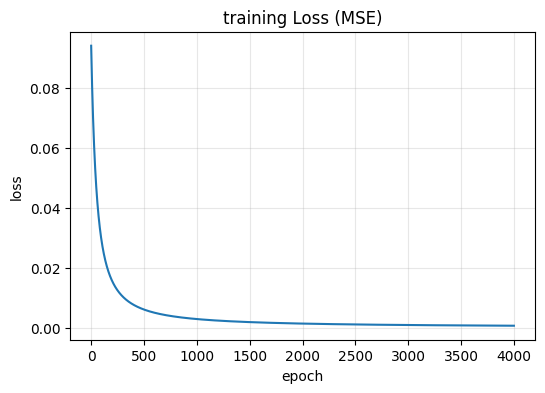

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title('training Loss (MSE)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True, alpha=0.3)
plt.show()

## 3) Outcome

- Loss decreases during training, showing successful gradient-based learning on the sample.
- Final prediction is computed from the sigmoid output using threshold 0.5.